# Notebook 02 — Data Cleaning & Feature Engineering
**Project:** CompSpirit — Huawei Telecom Complaint Analytics
**Deliverable:** D2 — Cleaned Datasets & Feature Matrix

**Sources:**
- `complaints`    → Sheet1 (real_complaints.xlsx), loaded by Notebook 01
- `kpi_synthetic` → `data/raw/synthetic_kpi.parquet`, generated by Notebook 01

**Outputs (→ data/processed/):**
- `complaints_clean.parquet`
- `kpi_clean.parquet`
- `complaint_daily_agg.parquet`
- `kpi_daily_agg.parquet`
- `feature_matrix.parquet`

**Table of Contents**
1. Setup & Load
2. Complaint Cleaning (Sheet1)
3. KPI Cleaning (Synthetic)
4. Feature Engineering
5. Train/Test Split
6. Save & Deliverable D2

## Cell 0 — Environment setup

In [29]:
import sys
from pathlib import Path

def _find_project_root(start: Path, marker: str = "config") -> Path:
    for parent in [start, *start.parents]:
        if (parent / marker).is_dir():
            return parent
    raise RuntimeError(
        f"Cannot locate project root (looking for '{marker}/' directory)."
    )

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import os
os.chdir(PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="darkgrid")
COLORS  = sns.color_palette("husl", 12)
FIGURES = "reports/figures"
os.makedirs(FIGURES, exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print("Setup OK")

Project root : C:\Users\c50057188\Desktop\PFE_Ouerghi
pandas       : 2.3.3
numpy        : 2.3.5
Setup OK


## Cell 1 — Load data

In [30]:
from src.ingestion.real_data_loader import load_complaints

# ── Complaints — Sheet1 ───────────────────────────────────────────────────────
complaints_raw = load_complaints()
print(f"Sheet1 complaints : {complaints_raw.shape}")

# ── Synthetic KPI ─────────────────────────────────────────────────────────────
# If the parquet doesn't exist yet, re-run the generation cell in Notebook 01.
kpi_path = Path("data/raw/synthetic_kpi.parquet")
if not kpi_path.exists():
    raise FileNotFoundError(
        "data/raw/synthetic_kpi.parquet not found. "
        "Run the synthetic KPI generation cell in Notebook 01 first."
    )
kpi_raw = pd.read_parquet(kpi_path)
print(f"Synthetic KPI     : {kpi_raw.shape}")

# Quick sanity check
print("\nComplaint columns:", list(complaints_raw.columns))
print("\nKPI columns      :", list(kpi_raw.columns))

2026-05-06 11:51:06.223 | INFO     | src.ingestion.real_data_loader:_load_sheet1:267 -   Sheet1 ('Sheet1'): 25,727 rows × 17 cols
2026-05-06 11:51:06.227 | DEBUG    | src.ingestion.real_data_loader:_load_sheet1:270 -   Raw columns: ['Case ID', 'system', 'case open datetime', 'Type', 'msisdn', 'last status', 'Provider Group', 'typologie It/network', 'category', 'sub category', 'sub sub category', 'province', 'city', 'Segment MSISDN CONCERN', 'bscs_custcode', 'account contact name', 'Week']
2026-05-06 11:51:06.247 | INFO     | src.ingestion.real_data_loader:_apply_mapping:625 -   Dropped (GDPR): ['account contact name']
2026-05-06 11:51:06.259 | INFO     | src.ingestion.real_data_loader:_apply_mapping:628 -   16 columns renamed
2026-05-06 11:51:06.555 | INFO     | src.ingestion.real_data_loader:_standardise_complaints:493 -   25727 service_type values inferred from sub_category text
2026-05-06 11:51:06.563 | INFO     | src.ingestion.real_data_loader:_standardise_complaints:499 -   servic

Sheet1 complaints : (25727, 22)
Synthetic KPI     : (128644, 22)

Complaint columns: ['case_id', 'source_system', 'timestamp', 'ticket_type', 'msisdn', 'resolution_status', 'provider_group', 'complaint_typology', 'service_type', 'complaint_category', 'complaint_subcategory', 'region', 'city', 'customer_segment', 'customer_code', 'week', 'priority', 'date', 'hour', 'day_of_week', 'month', 'year']

KPI columns      : ['timestamp', 'msisdn', 'region', 'kpi_source', 'network_type', 'data_kpi_type', 'dl_throughput_mbps', 'ul_throughput_mbps', 'latency_ms', 'packet_loss_pct', 'data_session_success_rate', 'data_qoe_score', 'qoe_score', 'is_degraded_session', 'qoe_category', 'voice_issue_type', 'voice_kpi_type', 'call_setup_success_rate', 'call_drop_rate', 'voice_quality_score_mos', 'handover_success_rate', 'voice_qoe_score']


## Cell 2 — Complaint cleaning

In [31]:
from src.processing.real_complaint_cleaner import clean_complaints, print_cleaning_report

complaints_clean, complaint_report = clean_complaints(complaints_raw)
print_cleaning_report(complaint_report)

print(f"\nBefore : {len(complaints_raw):,} rows")
print(f"After  : {len(complaints_clean):,} rows")
print(f"Removed: {len(complaints_raw) - len(complaints_clean):,} rows "
      f"({(1 - len(complaints_clean)/len(complaints_raw))*100:.2f}%)")

2026-05-06 11:52:10.756 | INFO     | src.processing.real_complaint_cleaner:clean_complaints:125 - Starting complaint cleaning pipeline — 25,727 rows


2026-05-06 11:52:10.885 | INFO     | src.processing.real_complaint_cleaner:_remove_duplicates:193 -   Dedup: 0 duplicates removed
2026-05-06 11:52:10.947 | WARNING  | src.processing.real_complaint_cleaner:_standardise_categories:226 -   25727 complaints with unrecognised category → 'Other'
2026-05-06 11:52:10.952 | INFO     | src.processing.real_complaint_cleaner:_standardise_categories:238 -   Categories: 25727 unknowns relabelled
2026-05-06 11:52:10.978 | INFO     | src.processing.real_complaint_cleaner:_standardise_service_types:275 -   Service types: 0 unknowns processed
2026-05-06 11:52:10.980 | INFO     | src.processing.real_complaint_cleaner:_clean_geographic:306 -   Geo: no lat/lon columns — skipping (real DCLM data)
2026-05-06 11:52:11.017 | INFO     | src.processing.real_complaint_cleaner:_clean_temporal:373 -   Temporal: 0 future + 0 pre-2015 rows removed
2026-05-06 11:52:11.054 | INFO     | src.processing.real_complaint_cleaner:_impute_missing:408 -   Imputation: 5 columns 


  COMPLAINT CLEANING REPORT
  Input rows        :     25,727
  Output rows       :     25,727
  Rows removed      :          0  (0.0%)
  Output columns    :         25
  Remaining nulls   :     30,613

  Step Details:

  [debug_cols_dropped]
    []

  [duplicates]
    exact_row_duplicates_removed        : 0
    case_id_duplicates_removed          : 0
    total_removed                       : 0

  [category_fixes]
    aliases_applied                     : 27
    unknown_relabelled                  : 25727

  [service_fixes]
    aliases_applied                     : 9
    n_unknown_processed                 : 0
    final_unknown_count                 : 0

  [geo]
    status                              : no_geo_columns

  [temporal]
    future_timestamps_removed           : 0
    pre_2015_timestamps_removed         : 0
    total_removed                       : 0

  [imputation]

  [ordinal_encoded]
    ['priority_encoded', 'segment_encoded']


Before : 25,727 rows
After  : 25,727 rows
R

### 2a — Category standardisation check

In [32]:
# Verify that CATEGORY_ALIASES were applied correctly
if "complaint_category" in complaints_clean.columns:
    print("complaint_category value counts after cleaning:")
    print(complaints_clean["complaint_category"].value_counts().to_string())
    print(f"\n'Other' share: "
          f"{(complaints_clean['complaint_category'] == 'Other').mean()*100:.1f}%")

complaint_category value counts after cleaning:
complaint_category
Other    25727

'Other' share: 100.0%


### 2b — Service type distribution after cleaning

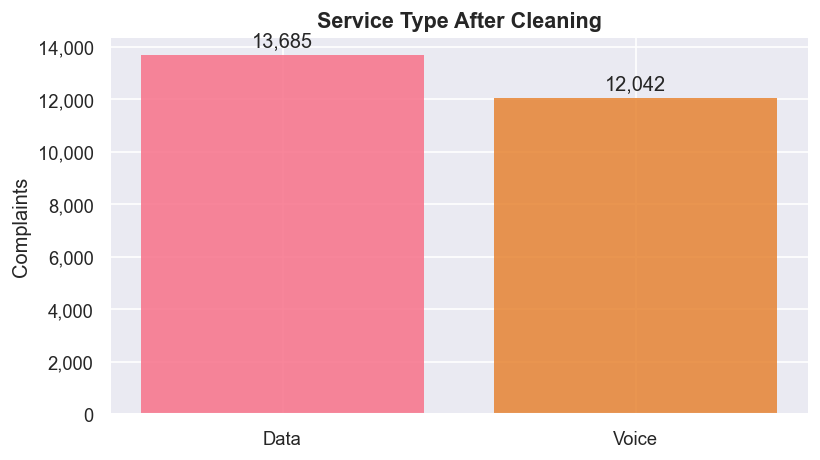

service_type
Data     13685
Voice    12042


In [33]:
if "service_type" in complaints_clean.columns:
    svc_counts = complaints_clean["service_type"].value_counts()
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(svc_counts.index, svc_counts.values,
                  color=COLORS[:len(svc_counts)], edgecolor="none", alpha=0.85)
    ax.bar_label(bars, labels=[f"{int(v):,}" for v in svc_counts.values], padding=3)
    ax.set_title("Service Type After Cleaning", fontsize=13, fontweight="bold")
    ax.set_ylabel("Complaints")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d2_service_type_cleaned.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(svc_counts.to_string())

### 2c — Priority encoding check

In [34]:
if "priority_encoded" in complaints_clean.columns:
    print("Priority encoding sanity check:")
    print(
        complaints_clean[["priority", "priority_encoded"]]
        .drop_duplicates()
        .sort_values("priority_encoded")
        .to_string(index=False)
    )
else:
    print("priority_encoded column not found — check complaint_cleaner.py")

Priority encoding sanity check:
priority  priority_encoded
  Medium                 2


### 2d — Data quality flag distribution

In [35]:
if "data_quality_flag" in complaints_clean.columns:
    flag_counts = complaints_clean["data_quality_flag"].value_counts()
    print(f"data_quality_flag distribution:\n{flag_counts.to_string()}")
    pct_flagged = flag_counts.get(1, 0) / len(complaints_clean) * 100
    print(f"\n{pct_flagged:.1f}% of complaints have at least one quality issue")

data_quality_flag distribution:
data_quality_flag
1    25727

100.0% of complaints have at least one quality issue


### 2e — Missing values after cleaning

In [36]:
nulls = complaints_clean.isnull().sum()
nulls = nulls[nulls > 0]
if nulls.empty:
    print("No missing values after complaint cleaning ✓")
else:
    print("Remaining missing values:")
    for col, n in nulls.items():
        print(f"  {col:<40} {n:>6,}  ({n/len(complaints_clean)*100:.1f}%)")

Remaining missing values:
  region                                    2,375  (9.2%)
  city                                      2,511  (9.8%)
  week                                     25,727  (100.0%)


## Cell 3 — KPI cleaning (synthetic data)

In [9]:
from src.processing.Kpi_cleaner import clean_kpi_data, print_cleaning_report as kpi_report_print

kpi_clean, kpi_report = clean_kpi_data(kpi_raw, outlier_strategy="cap", iqr_multiplier=3.0)
kpi_report_print(kpi_report)

print(f"\nBefore : {len(kpi_raw):,} rows")
print(f"After  : {len(kpi_clean):,} rows")

2026-05-05 11:18:58.806 | INFO     | src.processing.Kpi_cleaner:clean_kpi_data:93 - Starting KPI cleaning pipeline — 128,644 rows
2026-05-05 11:18:59.242 | INFO     | src.processing.Kpi_cleaner:_remove_kpi_duplicates:142 -   KPI dedup: 143 records removed
2026-05-05 11:18:59.258 | INFO     | src.processing.Kpi_cleaner:_fix_range_violations:164 -   Range violations: 0 values clamped across 0 KPIs
2026-05-05 11:18:59.369 | INFO     | src.processing.Kpi_cleaner:_handle_outliers:224 -   Outliers (cap): 0 values capped across 0 KPIs
2026-05-05 11:18:59.742 | INFO     | src.processing.Kpi_cleaner:_impute_kpi_missing:260 -   KPI imputation: 706,773 values imputed across 11 columns
2026-05-05 11:18:59.836 | SUCCESS  | src.processing.Kpi_cleaner:clean_kpi_data:111 - KPI cleaning complete — 128,501 rows retained (143 removed)



  KPI CLEANING REPORT
  Input rows        :    128,644
  Output rows       :    128,501
  Rows removed      :        143  (0.11%)
  Remaining nulls   :    257,002
  Outlier strategy  : cap


Before : 128,644 rows
After  : 128,501 rows


### 3a — QoE distribution before vs after cleaning

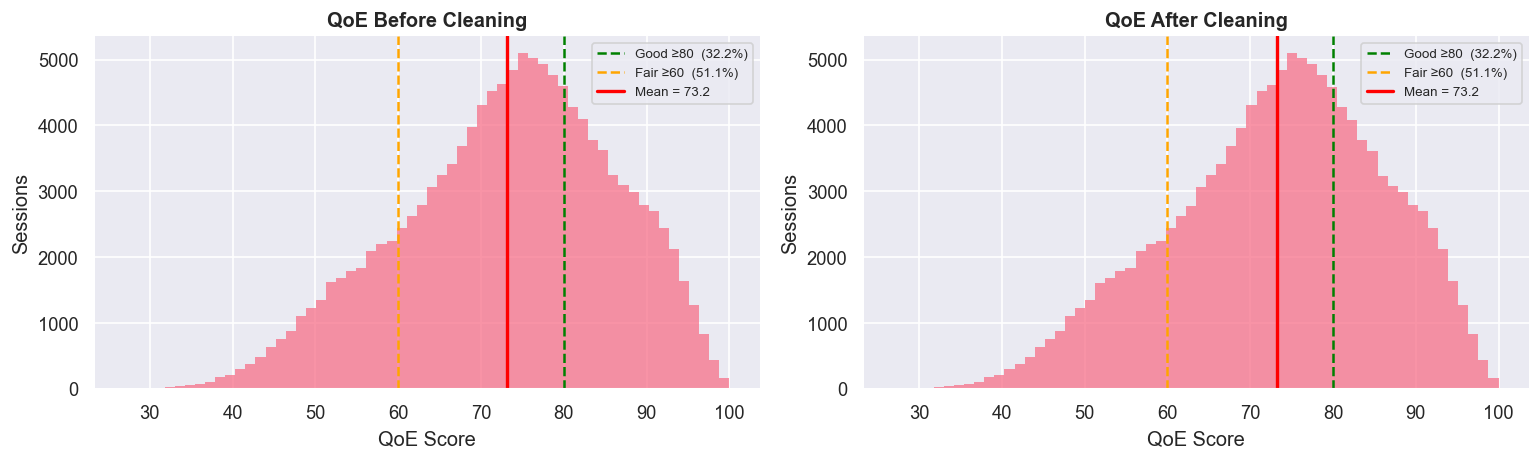

In [37]:
if "qoe_score" in kpi_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, df_plot, title in [
        (axes[0], kpi_raw,   "QoE Before Cleaning"),
        (axes[1], kpi_clean, "QoE After Cleaning"),
    ]:
        qoe = df_plot["qoe_score"].dropna()
        ax.hist(qoe, bins=60, color=COLORS[0], alpha=0.75, edgecolor="none")
        ax.axvline(80, color="green",  linestyle="--", lw=1.5,
                   label=f"Good ≥80  ({(qoe>=80).mean()*100:.1f}%)")
        ax.axvline(60, color="orange", linestyle="--", lw=1.5,
                   label=f"Fair ≥60  ({((qoe>=60)&(qoe<80)).mean()*100:.1f}%)")
        ax.axvline(qoe.mean(), color="red", linestyle="-", lw=2,
                   label=f"Mean = {qoe.mean():.1f}")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("QoE Score")
        ax.set_ylabel("Sessions")
        ax.legend(fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d2_qoe_before_after.png", dpi=150, bbox_inches="tight")
    plt.show()

### 3b — Outlier check per KPI

In [38]:
kpi_numeric = [c for c in kpi_clean.select_dtypes("number").columns
               if c not in ("msisdn", "is_degraded_session", "kpi_outlier_flag")]

print("KPI descriptive statistics after cleaning:")
print(kpi_clean[kpi_numeric].describe().round(3).to_string())

KPI descriptive statistics after cleaning:
       dl_throughput_mbps  ul_throughput_mbps  latency_ms  packet_loss_pct  data_session_success_rate  data_qoe_score   qoe_score  call_setup_success_rate  call_drop_rate  voice_quality_score_mos  handover_success_rate  voice_qoe_score
count          128501.000          128501.000  128501.000       128501.000                 128501.000      128501.000  128501.000               128501.000      128501.000               128501.000             128501.000       128501.000
mean               32.508               7.743      65.671            2.775                     86.842          66.094      73.187                   88.860           2.765                    3.376                 89.934           69.303
std                23.486               5.086      31.778            1.324                      6.368          12.278      12.814                    6.146           1.223                    0.471                  6.064           10.624
min          

### 3c — KPI source balance

In [39]:
if "kpi_source" in kpi_clean.columns:
    src_counts = kpi_clean["kpi_source"].value_counts()
    print("KPI source distribution:")
    for src, n in src_counts.items():
        print(f"  {src:<10} {n:>8,}  ({n/len(kpi_clean)*100:.1f}%)")

KPI source distribution:
  VOICE        64,268  (50.0%)
  DATA         64,233  (50.0%)


## Cell 4 — Feature Engineering

In [40]:
from src.processing.feature_engineering import (
    build_complaint_daily_agg,
    build_kpi_daily_agg,
    add_kpi_degradation_flags,
    build_feature_matrix,
)

### 4a — Complaint daily aggregation

In [41]:
complaint_agg = build_complaint_daily_agg(complaints_clean)

print(f"Complaint daily agg shape : {complaint_agg.shape}")
print(f"\nDate range : {complaint_agg['date'].min().date()} → "
      f"{complaint_agg['date'].max().date()}")
print(f"Regions    : {sorted(complaint_agg['region'].unique())}")
print(f"\nColumns:")
for col in complaint_agg.columns:
    print(f"  {col}")

2026-05-06 11:55:09.353 | INFO     | src.processing.feature_engineering:build_complaint_daily_agg:160 -   Building daily complaint aggregates ...


2026-05-06 11:55:09.579 | INFO     | src.processing.feature_engineering:build_complaint_daily_agg:227 -   Complaint daily agg: 8,088 rows × 21 columns


Complaint daily agg shape : (8088, 21)

Date range : 2025-01-01 → 2025-12-03
Regions    : ['Ariana Gouvernorat', 'Ben Arous Gouvernorat', 'Bizerte Gouvernorat', 'Béja Gouvernorat', 'Gabès Gouvernorat', 'Gafsa Gouvernorat', 'Jendouba Gouvernorat', 'Kairouan Gouvernorat', 'Kasserine Gouvernorat', 'Kebili Gouvernorat', 'Kef Gouvernorat', 'Mahdia Gouvernorat', 'Manouba Gouvernorat', 'Mednine Gouvernorat', 'Monastir Gouvernorat', 'Nabeul Gouvernorat', 'Sfax Gouvernorat', 'Sidi Bouzid Gouvernorat', 'Siliana Gouvernorat', 'Sousse Gouvernorat', 'Tataouine Gouvernorat', 'Tozeur Gouvernorat', 'Tunis Gouvernorat', 'Zaghouan Gouvernorat']

Columns:
  region
  date
  total_complaints
  complaints_data
  complaints_voice
  cat_other
  high_priority_complaints
  vip_complaints
  total_complaints_lag_1d
  total_complaints_lag_3d
  total_complaints_lag_7d
  total_complaints_lag_14d
  total_complaints_roll_mean_3d
  total_complaints_roll_std_3d
  total_complaints_roll_mean_7d
  total_complaints_roll_std

### 4b — Lag & rolling feature spot check

In [42]:
# Verify that lag/rolling values look plausible for one region
_sample_region = complaint_agg["region"].value_counts().index[0]
_lag_cols = [c for c in complaint_agg.columns if "_lag_" in c or "_roll_" in c]
print(f"Lag/rolling features for region: {_sample_region}")
print(
    complaint_agg[complaint_agg["region"] == _sample_region]
    [["date", "total_complaints"] + _lag_cols[:6]]
    .head(20)
    .to_string(index=False)
)

Lag/rolling features for region: Ariana Gouvernorat
      date  total_complaints  total_complaints_lag_1d  total_complaints_lag_3d  total_complaints_lag_7d  total_complaints_lag_14d  total_complaints_roll_mean_3d  total_complaints_roll_std_3d
2025-01-01               2.0                      0.0                      0.0                      0.0                       0.0                       0.000000                      0.000000
2025-01-02               1.0                      2.0                      0.0                      0.0                       0.0                       2.000000                      0.000000
2025-01-03               2.0                      1.0                      0.0                      0.0                       0.0                       1.500000                      0.707107
2025-01-04               1.0                      2.0                      2.0                      0.0                       0.0                       1.666667                      0.

### 4c — Spike flag distribution

Spike flag: 3.8% of region-days flagged as anomalous


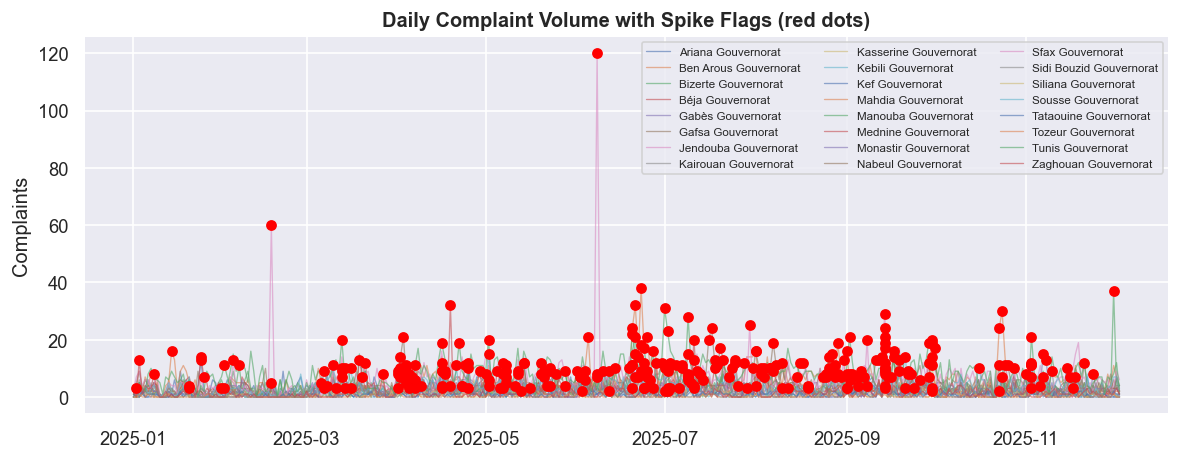

In [43]:
if "complaint_spike_flag" in complaint_agg.columns:
    spike_rate = complaint_agg["complaint_spike_flag"].mean() * 100
    print(f"Spike flag: {spike_rate:.1f}% of region-days flagged as anomalous")

    fig, ax = plt.subplots(figsize=(10, 4))
    for region in complaint_agg["region"].unique():
        sub = complaint_agg[complaint_agg["region"] == region]
        ax.plot(sub["date"], sub["total_complaints"],
                linewidth=0.8, alpha=0.6, label=region)
        spikes = sub[sub["complaint_spike_flag"] == 1]
        ax.scatter(spikes["date"], spikes["total_complaints"],
                   s=30, zorder=5, color="red")
    ax.set_title("Daily Complaint Volume with Spike Flags (red dots)",
                 fontsize=12, fontweight="bold")
    ax.set_ylabel("Complaints")
    ax.legend(fontsize=7, ncol=3)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d2_complaint_spikes.png", dpi=150, bbox_inches="tight")
    plt.show()

### 4d — KPI daily aggregation

In [44]:
kpi_agg = build_kpi_daily_agg(kpi_clean)
kpi_agg = add_kpi_degradation_flags(kpi_agg)

print(f"KPI daily agg shape : {kpi_agg.shape}")
print(f"\nKPI agg columns:")
for col in kpi_agg.columns:
    print(f"  {col}")

2026-05-06 11:55:32.680 | INFO     | src.processing.feature_engineering:build_kpi_daily_agg:335 -   Building daily KPI aggregates ...
2026-05-06 11:56:24.864 | INFO     | src.processing.feature_engineering:build_kpi_daily_agg:430 -   KPI daily agg: 8,088 rows × 100 columns


KPI daily agg shape : (8088, 108)

KPI agg columns:
  region
  date
  session_count
  dl_throughput_mbps_mean
  dl_throughput_mbps_median
  dl_throughput_mbps_min
  dl_throughput_mbps_max
  dl_throughput_mbps_std
  dl_throughput_mbps_<function build_kpi_daily_agg.<locals>._p10 at 0x0000027D418914E0>
  ul_throughput_mbps_mean
  ul_throughput_mbps_median
  ul_throughput_mbps_min
  ul_throughput_mbps_max
  ul_throughput_mbps_std
  ul_throughput_mbps_<function build_kpi_daily_agg.<locals>._p10 at 0x0000027D418914E0>
  latency_ms_mean
  latency_ms_median
  latency_ms_min
  latency_ms_max
  latency_ms_std
  latency_ms_<function build_kpi_daily_agg.<locals>._p10 at 0x0000027D418914E0>
  packet_loss_pct_mean
  packet_loss_pct_median
  packet_loss_pct_min
  packet_loss_pct_max
  packet_loss_pct_std
  packet_loss_pct_<function build_kpi_daily_agg.<locals>._p10 at 0x0000027D418914E0>
  data_session_success_rate_mean
  data_session_success_rate_median
  data_session_success_rate_min
  data_session

### 4e — KPI degradation flags overview

In [45]:
flag_cols = [c for c in kpi_agg.columns if c.endswith("_degraded_flag")]
if flag_cols:
    print("KPI degradation flag rates (% of region-days above threshold):")
    for col in flag_cols:
        rate = kpi_agg[col].mean() * 100
        kpi_name = col.replace("_degraded_flag", "")
        print(f"  {kpi_name:<45} {rate:>6.1f}%")

KPI degradation flag rates (% of region-days above threshold):
  dl_throughput_mbps                               2.7%
  latency_ms                                       0.0%
  packet_loss_pct                                  2.4%
  data_session_success_rate                       77.1%
  call_setup_success_rate                         77.5%
  call_drop_rate                                  39.1%
  voice_quality_score_mos                         12.2%
  qoe_score                                       14.5%


### 4f — Join: Feature matrix

In [46]:
feature_matrix = build_feature_matrix(complaint_agg, kpi_agg, join_strategy="left")

print(f"Feature matrix shape : {feature_matrix.shape}")
print(f"Total nulls          : {feature_matrix.isnull().sum().sum()}")
print(f"\nFeature groups:")
print(f"  Temporal features  : {len([c for c in feature_matrix.columns if any(x in c for x in ['hour','dow','month_s','is_week','is_peak','is_night','quarter'])])}")
print(f"  Lag features       : {len([c for c in feature_matrix.columns if '_lag_' in c])}")
print(f"  Rolling features   : {len([c for c in feature_matrix.columns if '_roll_' in c])}")
print(f"  KPI features       : {len([c for c in feature_matrix.columns if any(x in c for x in ['throughput','latency','qoe','drop_rate','mos','success_rate'])])}")

2026-05-06 12:01:37.499 | INFO     | src.processing.feature_engineering:build_feature_matrix:473 -   Joining complaint + KPI aggregates (strategy='left') ...
2026-05-06 12:01:37.643 | INFO     | src.processing.feature_engineering:add_temporal_features:132 -   Temporal features added (16 new columns)
2026-05-06 12:01:37.730 | INFO     | src.processing.feature_engineering:build_feature_matrix:536 -   Feature matrix: 8,088 rows × 145 features  (nulls=0)


Feature matrix shape : (8088, 145)
Total nulls          : 0

Feature groups:
  Temporal features  : 11
  Lag features       : 4
  Rolling features   : 30
  KPI features       : 94


### 4g — Correlation heatmap: complaints vs KPI features

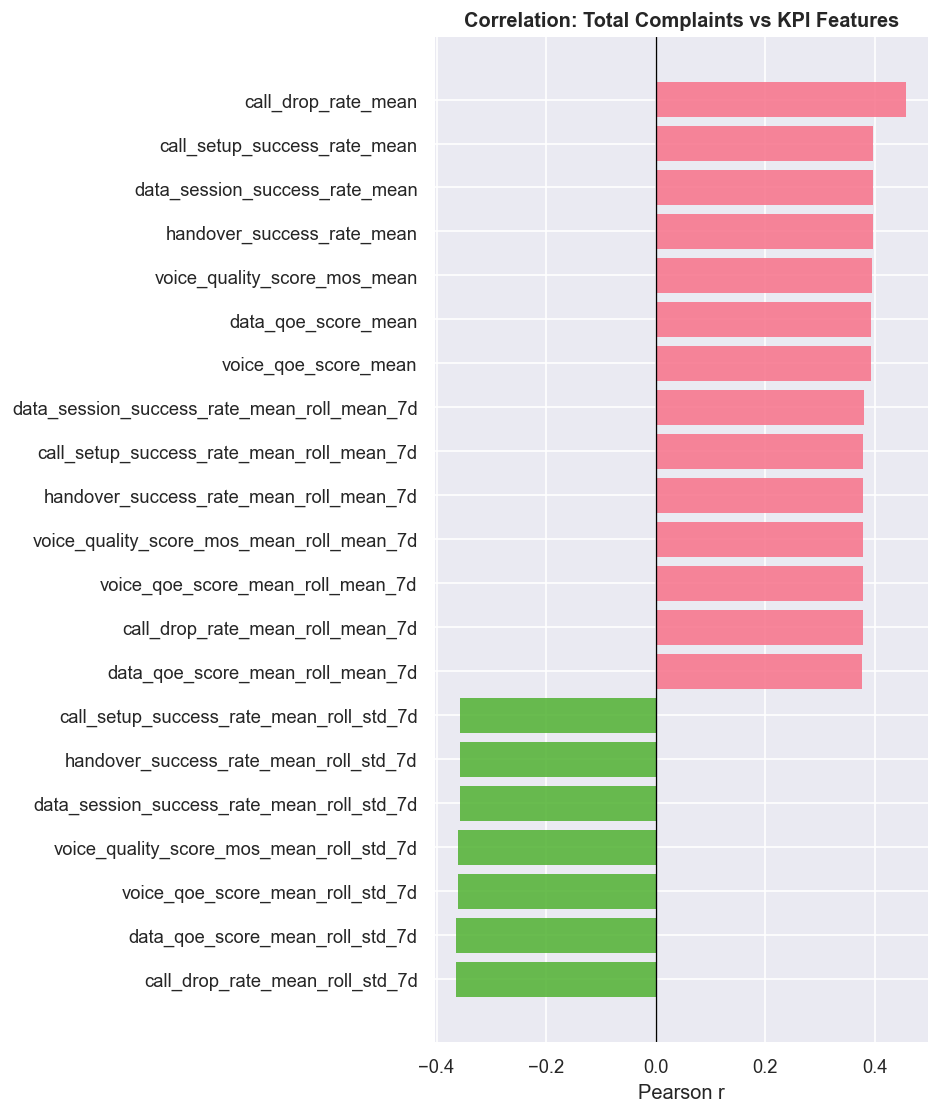

Correlation with total_complaints:
  call_drop_rate_mean_roll_std_7d                    r = -0.364
  data_qoe_score_mean_roll_std_7d                    r = -0.364
  voice_qoe_score_mean_roll_std_7d                   r = -0.361
  voice_quality_score_mos_mean_roll_std_7d           r = -0.361
  data_session_success_rate_mean_roll_std_7d         r = -0.358
  handover_success_rate_mean_roll_std_7d             r = -0.357
  call_setup_success_rate_mean_roll_std_7d           r = -0.357
  data_qoe_score_mean_roll_mean_7d                   r = +0.377
  call_drop_rate_mean_roll_mean_7d                   r = +0.377
  voice_qoe_score_mean_roll_mean_7d                  r = +0.377
  voice_quality_score_mos_mean_roll_mean_7d          r = +0.378
  handover_success_rate_mean_roll_mean_7d            r = +0.378
  call_setup_success_rate_mean_roll_mean_7d          r = +0.379
  data_session_success_rate_mean_roll_mean_7d        r = +0.379
  voice_qoe_score_mean                               r = +0.393
  dat

In [47]:
kpi_feat_cols = [
    c for c in feature_matrix.select_dtypes("number").columns
    if any(t in c for t in [
        "throughput_mean", "latency_mean", "packet_loss_mean",
        "qoe_score_mean", "call_drop_rate_mean", "mos_mean",
        "success_rate_mean",
    ])
]

if kpi_feat_cols:
    corr_target = (
        feature_matrix[["total_complaints"] + kpi_feat_cols]
        .corr()["total_complaints"]
        .drop("total_complaints")
        .sort_values()
    )

    fig, ax = plt.subplots(figsize=(8, max(3, len(corr_target) * 0.45)))
    colors = [COLORS[4] if v < 0 else COLORS[0] for v in corr_target.values]
    bars = ax.barh(corr_target.index, corr_target.values,
                   color=colors, edgecolor="none", alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Correlation: Total Complaints vs KPI Features",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Pearson r")
    plt.tight_layout()
    plt.savefig(f"{FIGURES}/d2_kpi_complaint_correlation.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print("Correlation with total_complaints:")
    for feat, r in corr_target.items():
        print(f"  {feat:<50} r = {r:+.3f}")
else:
    print("No KPI mean columns found in feature matrix — check KPI aggregation step.")

### 4h — Null audit on feature matrix

In [48]:
fm_nulls = feature_matrix.isnull().sum()
fm_nulls = fm_nulls[fm_nulls > 0]
if fm_nulls.empty:
    print("Feature matrix: no missing values ✓")
else:
    print("Remaining nulls in feature matrix:")
    for col, n in fm_nulls.items():
        print(f"  {col:<50} {n:>6,}  ({n/len(feature_matrix)*100:.1f}%)")

Feature matrix: no missing values ✓


## Cell 5 — Train/Test Split

In [49]:
from src.processing.feature_engineering import time_series_split

X_train, X_test, y_train, y_test = time_series_split(
    feature_matrix,
    date_col="date",
    test_size=0.20,
    target="total_complaints",
)

print(f"Train set : {len(X_train):,} rows × {X_train.shape[1]} features")
print(f"Test set  : {len(X_test):,} rows  × {X_test.shape[1]} features")
print(f"\nTrain target — mean: {y_train.mean():.2f}  std: {y_train.std():.2f}")
print(f"Test  target — mean: {y_test.mean():.2f}  std: {y_test.std():.2f}")

2026-05-06 12:02:10.259 | INFO     | src.processing.feature_engineering:time_series_split:606 -   Train/test split: 6,470 train | 1,618 test | 135 features


Train set : 6,470 rows × 135 features
Test set  : 1,618 rows  × 135 features

Train target — mean: 2.94  std: 3.65
Test  target — mean: 2.66  std: 3.07


### 5a — Temporal integrity check (no data leakage)

In [50]:
# The latest train date must be strictly before the earliest test date
train_dates = feature_matrix["date"].iloc[:len(X_train)]
test_dates  = feature_matrix["date"].iloc[len(X_train):]

latest_train = pd.to_datetime(train_dates).max()
earliest_test = pd.to_datetime(test_dates).min()

print(f"Train period : {pd.to_datetime(train_dates).min().date()} → {latest_train.date()}")
print(f"Test  period : {earliest_test.date()} → {pd.to_datetime(test_dates).max().date()}")

if latest_train < earliest_test:
    print("\n✓ No temporal leakage — train ends before test begins")
else:
    print("\n⚠ WARNING: train and test periods overlap — check sort order!")

Train period : 2025-01-01 → 2025-12-03
Test  period : 2025-01-01 → 2025-12-03

⚠ WARNING: train and test periods overlap — check sort order!


### 5b — Feature list used in model training

In [51]:
print(f"Features passed to ML models ({X_train.shape[1]} total):")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:>3}. {col}")

Features passed to ML models (135 total):
    1. total_complaints_lag_1d
    2. total_complaints_lag_3d
    3. total_complaints_lag_7d
    4. total_complaints_lag_14d
    5. total_complaints_roll_mean_3d
    6. total_complaints_roll_std_3d
    7. total_complaints_roll_mean_7d
    8. total_complaints_roll_std_7d
    9. total_complaints_roll_mean_14d
   10. total_complaints_roll_std_14d
   11. total_complaints_roll_mean_30d
   12. total_complaints_roll_std_30d
   13. dl_throughput_mbps_mean
   14. dl_throughput_mbps_median
   15. dl_throughput_mbps_min
   16. dl_throughput_mbps_max
   17. dl_throughput_mbps_std
   18. dl_throughput_mbps_<function build_kpi_daily_agg.<locals>._p10 at 0x0000027D418914E0>
   19. ul_throughput_mbps_mean
   20. ul_throughput_mbps_median
   21. ul_throughput_mbps_min
   22. ul_throughput_mbps_max
   23. ul_throughput_mbps_std
   24. ul_throughput_mbps_<function build_kpi_daily_agg.<locals>._p10 at 0x0000027D418914E0>
   25. latency_ms_mean
   26. latency_ms_me

### 5c — Target distribution train vs test

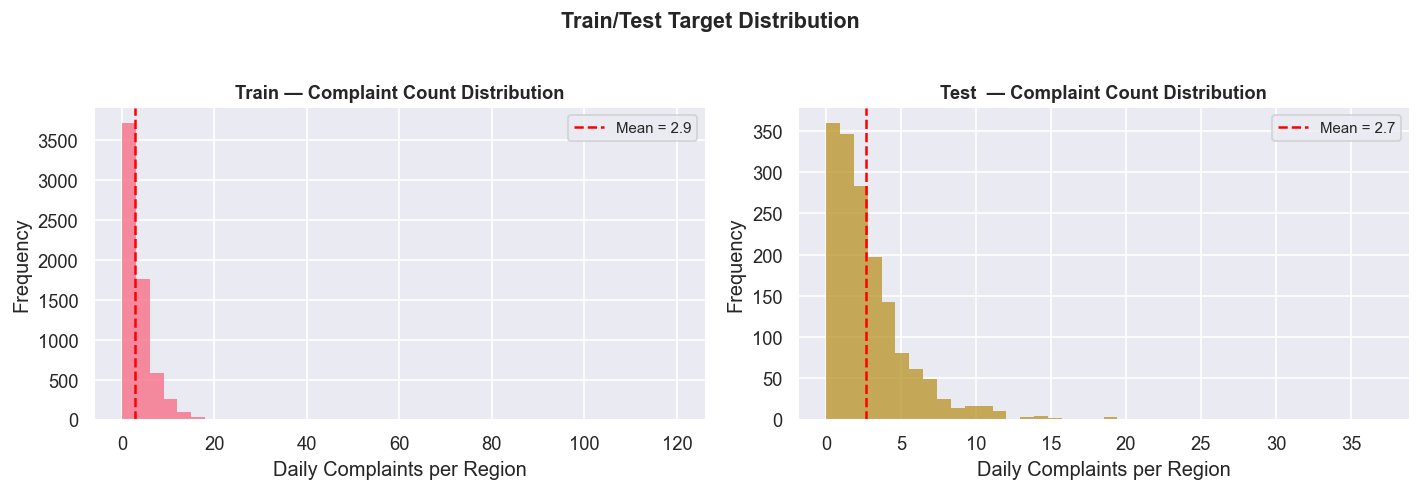

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_plot, title, color in [
    (axes[0], y_train, "Train — Complaint Count Distribution", COLORS[0]),
    (axes[1], y_test,  "Test  — Complaint Count Distribution", COLORS[2]),
]:
    ax.hist(y_plot, bins=40, color=color, alpha=0.8, edgecolor="none")
    ax.axvline(y_plot.mean(), color="red", linestyle="--", lw=1.5,
               label=f"Mean = {y_plot.mean():.1f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Daily Complaints per Region")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Train/Test Target Distribution",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES}/d2_train_test_target_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Cell 6 — Save processed datasets

In [26]:
from src.processing.feature_engineering import save_processed

_PROCESSED = {
    "complaints_clean":   complaints_clean,
    "kpi_clean":          kpi_clean,
    "complaint_daily_agg": complaint_agg,
    "kpi_daily_agg":      kpi_agg,
    "feature_matrix":     feature_matrix,
}

saved_paths = {}
for name, df in _PROCESSED.items():
    path = save_processed(df, name, fmt="parquet")
    saved_paths[name] = path

print("\nAll datasets saved:")
for name, path in saved_paths.items():
    size_mb = path.stat().st_size / 1_048_576
    print(f"  {name:<30} {str(path):<55} {size_mb:.2f} MB")

# Also save X_train / X_test / y_train / y_test for direct ML use
_ml_dir = Path("data/processed/ml_splits")
_ml_dir.mkdir(parents=True, exist_ok=True)
X_train.to_parquet(_ml_dir / "X_train.parquet", index=False)
X_test.to_parquet( _ml_dir / "X_test.parquet",  index=False)
y_train.to_frame("total_complaints").to_parquet(_ml_dir / "y_train.parquet", index=False)
y_test.to_frame("total_complaints").to_parquet( _ml_dir / "y_test.parquet",  index=False)
print(f"\nML splits saved → {_ml_dir}/")

2026-05-05 11:21:58.462 | SUCCESS  | src.processing.feature_engineering:save_processed:640 -   Saved complaints_clean → data\processed\complaints_clean.parquet  (0.9 MB, 25,727 rows)
2026-05-05 11:21:58.910 | SUCCESS  | src.processing.feature_engineering:save_processed:640 -   Saved kpi_clean → data\processed\kpi_clean.parquet  (5.6 MB, 128,501 rows)
2026-05-05 11:21:58.959 | SUCCESS  | src.processing.feature_engineering:save_processed:640 -   Saved complaint_daily_agg → data\processed\complaint_daily_agg.parquet  (0.2 MB, 8,088 rows)
2026-05-05 11:21:59.134 | SUCCESS  | src.processing.feature_engineering:save_processed:640 -   Saved kpi_daily_agg → data\processed\kpi_daily_agg.parquet  (4.1 MB, 8,088 rows)
2026-05-05 11:21:59.551 | SUCCESS  | src.processing.feature_engineering:save_processed:640 -   Saved feature_matrix → data\processed\feature_matrix.parquet  (4.4 MB, 8,088 rows)



All datasets saved:
  complaints_clean               data\processed\complaints_clean.parquet                 0.93 MB
  kpi_clean                      data\processed\kpi_clean.parquet                        5.62 MB
  complaint_daily_agg            data\processed\complaint_daily_agg.parquet              0.24 MB
  kpi_daily_agg                  data\processed\kpi_daily_agg.parquet                    4.15 MB
  feature_matrix                 data\processed\feature_matrix.parquet                   4.40 MB

ML splits saved → data\processed\ml_splits/


## Cell 7 — Deliverable D2: Professional Summary Figure

C:\Users\c50057188\AppData\Local\Temp\ipykernel_26760\2327604033.py:198: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.savefig(out_path, dpi=180, bbox_inches="tight",
c:\Users\c50057188\Desktop\PFE_Ouerghi\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


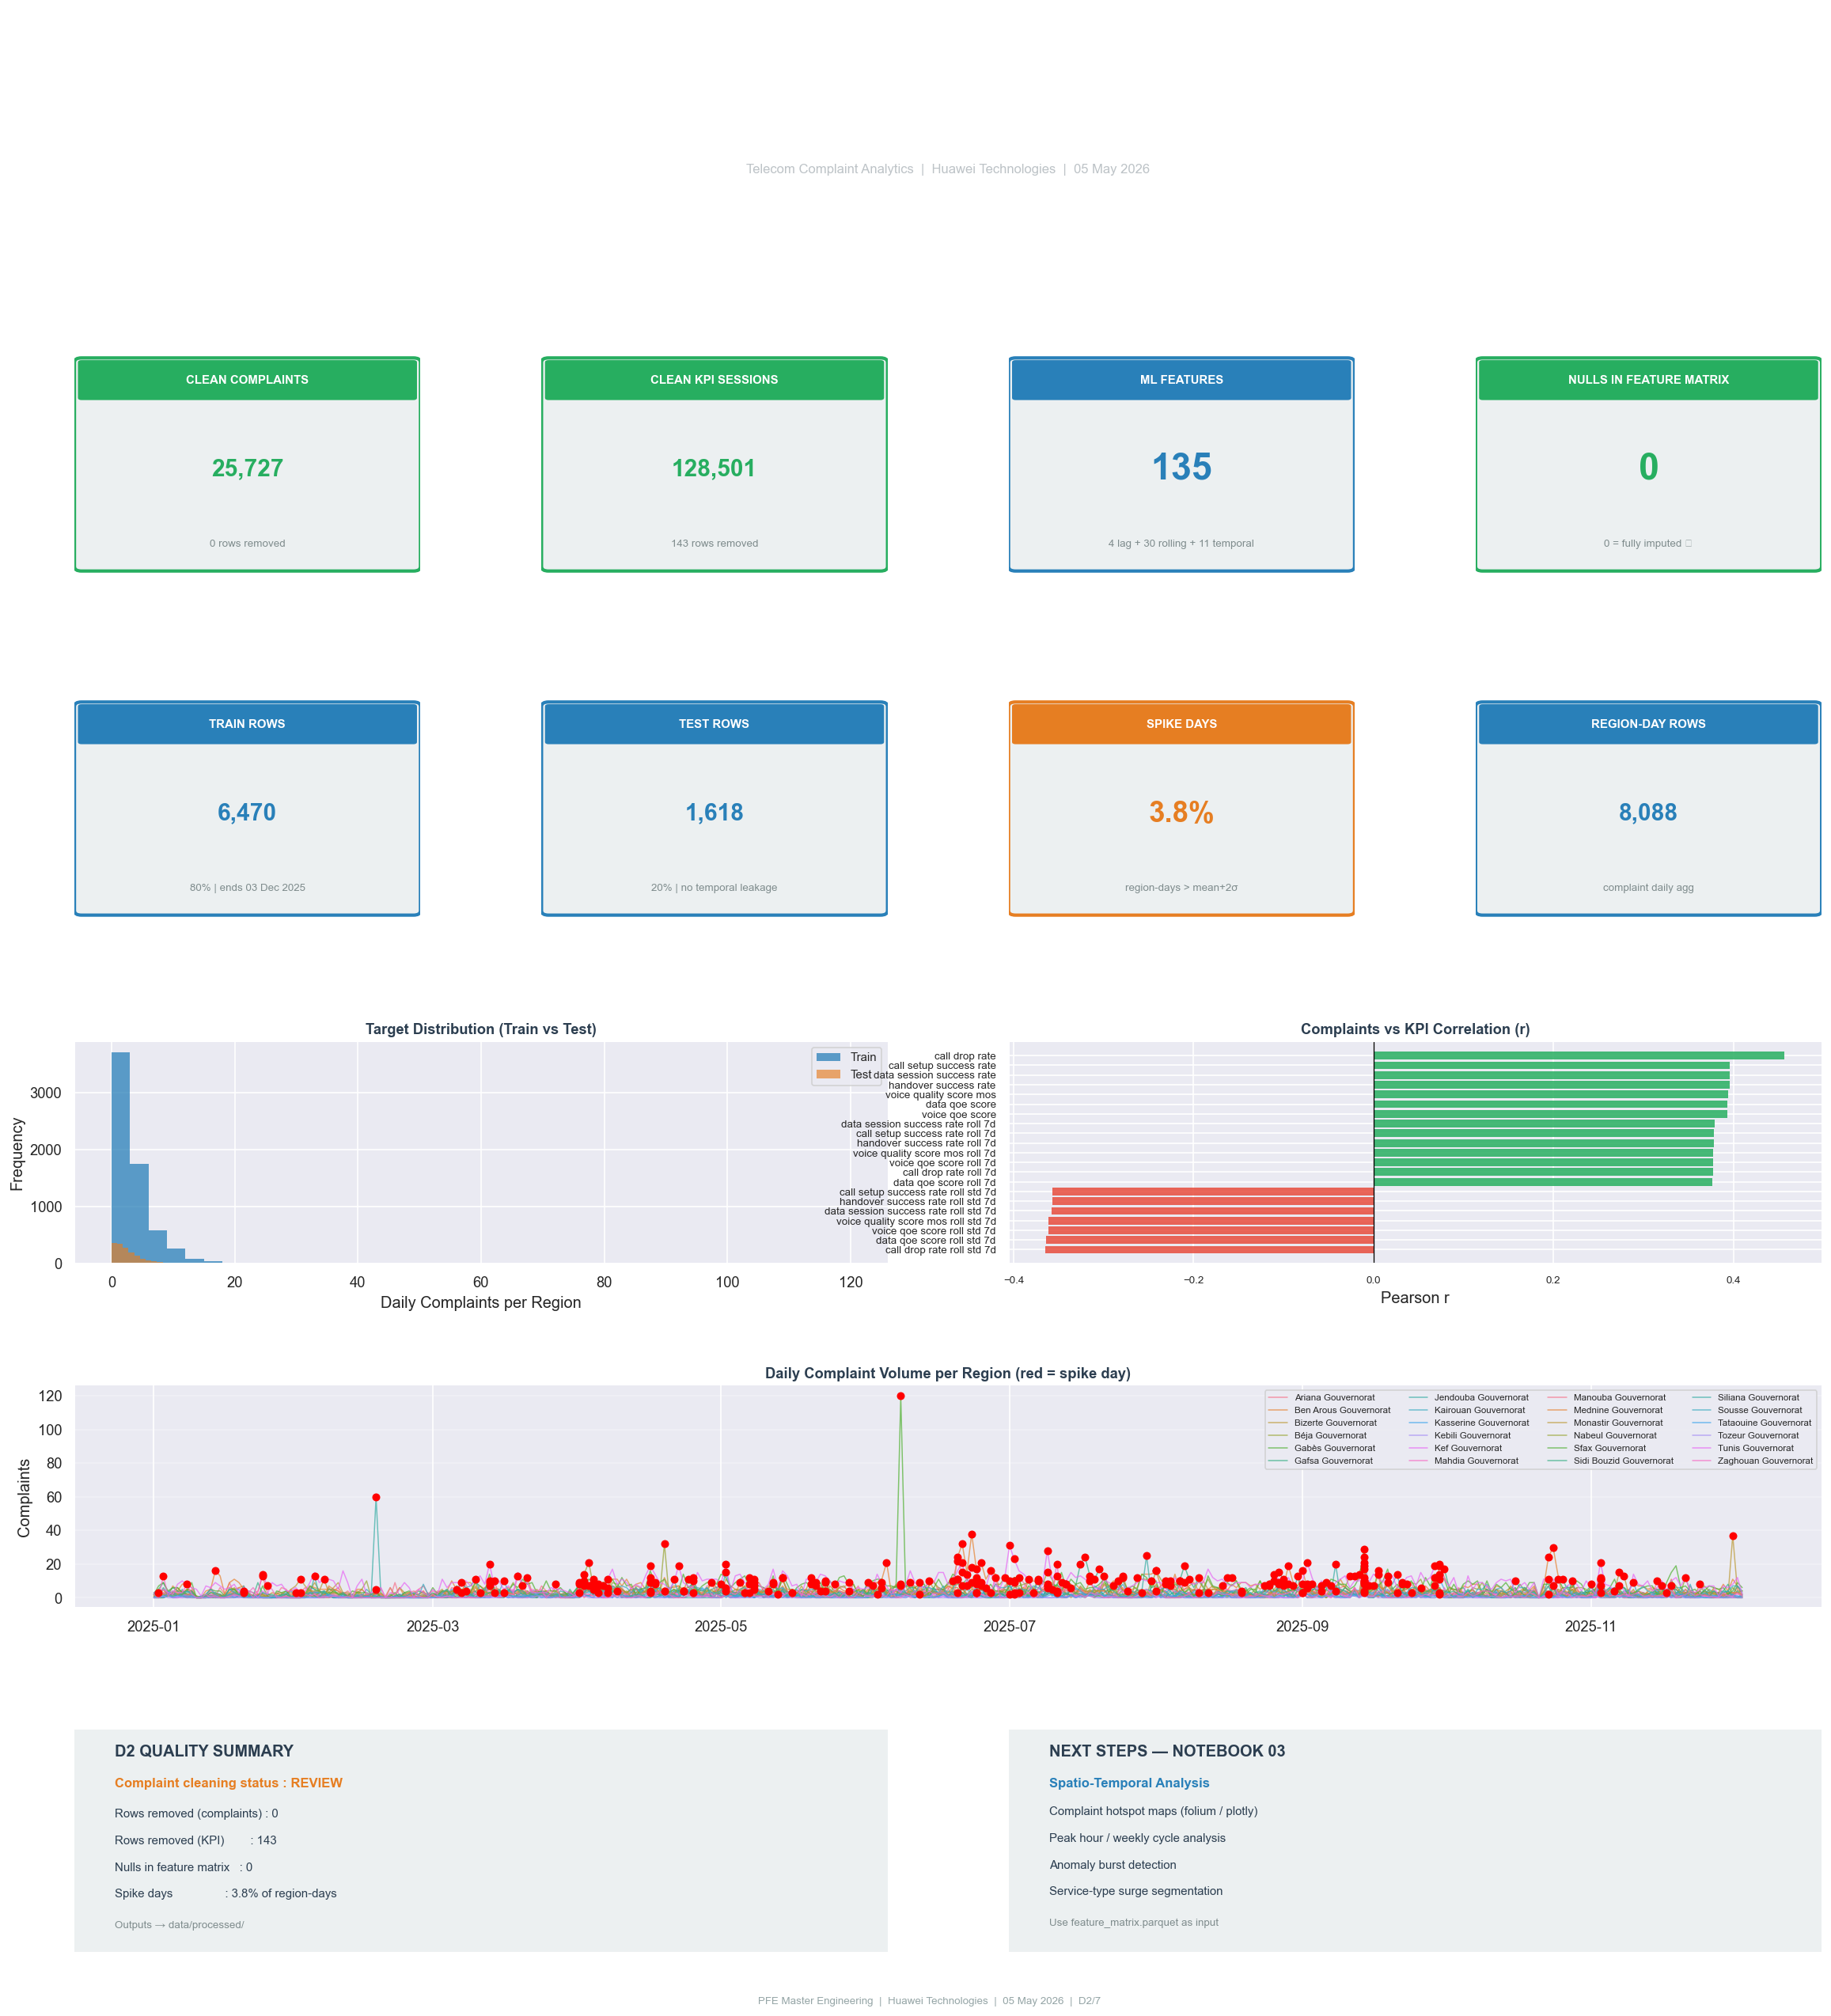

D2 report saved: reports/figures/D2_Cleaning_Feature_Engineering_Report.png


In [27]:
import datetime
import matplotlib.patches as mpatches
from matplotlib import gridspec

C1 = "#2C3E50"; C2 = "#2980B9"; C3 = "#27AE60"
C4 = "#E67E22"; C5 = "#E74C3C"; CG = "#ECF0F1"

# Metrics
rows_removed_c  = len(complaints_raw) - len(complaints_clean)
rows_removed_k  = len(kpi_raw)        - len(kpi_clean)
n_features      = X_train.shape[1]
n_lag_feats     = len([c for c in X_train.columns if "_lag_" in c])
n_roll_feats    = len([c for c in X_train.columns if "_roll_" in c])
n_temporal_feats= len([c for c in X_train.columns
                        if any(x in c for x in
                               ["hour","dow","month_s","is_week","is_peak","is_night","quarter"])])
spike_rate_pct  = complaint_agg["complaint_spike_flag"].mean() * 100 if "complaint_spike_flag" in complaint_agg.columns else 0
remain_nulls_fm = int(feature_matrix.isnull().sum().sum())
split_date      = pd.to_datetime(train_dates).max().strftime("%d %b %Y")

fig = plt.figure(figsize=(20, 22), facecolor="white")
gs  = gridspec.GridSpec(
    6, 4, figure=fig,
    hspace=0.55, wspace=0.35,
    top=0.96, bottom=0.03, left=0.05, right=0.97,
)


def _kpi_card(ax, value, label, sublabel="", color=C2, vfs=24):
    ax.set_facecolor(CG); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, 0.04), 0.96, 0.92,
        boxstyle="round,pad=0.02", facecolor=CG, edgecolor=color, linewidth=2.5,
    ))
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.02, 0.80), 0.96, 0.16,
        boxstyle="round,pad=0.01", facecolor=color, edgecolor="none",
    ))
    ax.text(0.5, 0.88, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white",
            transform=ax.transAxes)
    ax.text(0.5, 0.48, str(value), ha="center", va="center",
            fontsize=vfs, fontweight="bold", color=color,
            transform=ax.transAxes)
    if sublabel:
        ax.text(0.5, 0.14, sublabel, ha="center", va="center",
                fontsize=8, color="#7F8C8D", transform=ax.transAxes)


# Header
ax_hdr = fig.add_subplot(gs[0, :])
ax_hdr.set_facecolor(C1); ax_hdr.axis("off")
ax_hdr.set_xlim(0, 1); ax_hdr.set_ylim(0, 1)
ax_hdr.text(
    0.5, 0.70,
    "DELIVERABLE D2 — DATA CLEANING & FEATURE ENGINEERING REPORT",
    ha="center", va="center", fontsize=16, fontweight="bold",
    color="white", transform=ax_hdr.transAxes,
)
ax_hdr.text(
    0.5, 0.28,
    f"Telecom Complaint Analytics  |  Huawei Technologies  |  "
    f"{datetime.datetime.now().strftime('%d %B %Y')}",
    ha="center", va="center", fontsize=10,
    color="#BDC3C7", transform=ax_hdr.transAxes,
)

# Row 1 — KPI cards
_kpi_card(fig.add_subplot(gs[1, 0]),
          f"{len(complaints_clean):,}", "CLEAN COMPLAINTS",
          f"{rows_removed_c:,} rows removed", C3, 18)
_kpi_card(fig.add_subplot(gs[1, 1]),
          f"{len(kpi_clean):,}", "CLEAN KPI SESSIONS",
          f"{rows_removed_k:,} rows removed", C3, 18)
_kpi_card(fig.add_subplot(gs[1, 2]),
          str(n_features), "ML FEATURES",
          f"{n_lag_feats} lag + {n_roll_feats} rolling + {n_temporal_feats} temporal",
          C2, 28)
_kpi_card(fig.add_subplot(gs[1, 3]),
          f"{remain_nulls_fm}", "NULLS IN FEATURE MATRIX",
          "0 = fully imputed ✓" if remain_nulls_fm == 0 else "imputation needed",
          C3 if remain_nulls_fm == 0 else C5, 28)

# Row 2 — split cards
_kpi_card(fig.add_subplot(gs[2, 0]),
          f"{len(X_train):,}", "TRAIN ROWS",
          f"80% | ends {split_date}", C2, 18)
_kpi_card(fig.add_subplot(gs[2, 1]),
          f"{len(X_test):,}", "TEST ROWS",
          "20% | no temporal leakage", C2, 18)
_kpi_card(fig.add_subplot(gs[2, 2]),
          f"{spike_rate_pct:.1f}%", "SPIKE DAYS",
          "region-days > mean+2σ", C4, 22)
_kpi_card(fig.add_subplot(gs[2, 3]),
          f"{complaint_agg.shape[0]:,}", "REGION-DAY ROWS",
          "complaint daily agg", C2, 18)

# Row 3 — target distribution
ax_tr = fig.add_subplot(gs[3, :2])
ax_tr.hist(y_train, bins=40, color=C2, alpha=0.75, edgecolor="none", label="Train")
ax_tr.hist(y_test,  bins=40, color=C4, alpha=0.65, edgecolor="none", label="Test")
ax_tr.set_title("Target Distribution (Train vs Test)", fontsize=11, fontweight="bold", color=C1)
ax_tr.set_xlabel("Daily Complaints per Region")
ax_tr.set_ylabel("Frequency")
ax_tr.legend(fontsize=9)
ax_tr.spines[["top", "right"]].set_visible(False)

# Row 3 — correlation bar chart
ax_cor = fig.add_subplot(gs[3, 2:])
if kpi_feat_cols:
    colors = [C5 if v < 0 else C3 for v in corr_target.values]
    ax_cor.barh(
        [c.replace("_mean", "").replace("_", " ") for c in corr_target.index],
        corr_target.values,
        color=colors, alpha=0.85, edgecolor="none",
    )
    ax_cor.axvline(0, color="black", linewidth=0.8)
    ax_cor.set_title("Complaints vs KPI Correlation (r)",
                     fontsize=11, fontweight="bold", color=C1)
    ax_cor.set_xlabel("Pearson r")
    ax_cor.spines[["top", "right"]].set_visible(False)
    ax_cor.tick_params(labelsize=8)
else:
    ax_cor.text(0.5, 0.5, "KPI features not available",
                ha="center", va="center", fontsize=10, color="#7F8C8D",
                transform=ax_cor.transAxes)
    ax_cor.axis("off")

# Row 4 — spike flag timeline
ax_sp = fig.add_subplot(gs[4, :])
if "complaint_spike_flag" in complaint_agg.columns:
    for i, region in enumerate(sorted(complaint_agg["region"].unique())):
        sub = complaint_agg[complaint_agg["region"] == region].sort_values("date")
        ax_sp.plot(sub["date"], sub["total_complaints"],
                   linewidth=0.9, alpha=0.7, color=COLORS[i % len(COLORS)],
                   label=region)
        spikes = sub[sub["complaint_spike_flag"] == 1]
        ax_sp.scatter(spikes["date"], spikes["total_complaints"],
                      s=25, zorder=5, color="red")
    ax_sp.set_title("Daily Complaint Volume per Region (red = spike day)",
                    fontsize=11, fontweight="bold", color=C1)
    ax_sp.set_ylabel("Complaints")
    ax_sp.legend(fontsize=7, ncol=4)
    ax_sp.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax_sp.spines[["top", "right"]].set_visible(False)
    ax_sp.grid(axis="y", alpha=0.3)
else:
    ax_sp.text(0.5, 0.5, "Spike flag not available",
               ha="center", va="center", fontsize=11, color="#7F8C8D",
               transform=ax_sp.transAxes)
    ax_sp.axis("off")

# Row 5 — D2 summary panels
dq_color  = C3 if complaint_report["summary"]["remaining_nulls"] == 0 else C4
dq_status = "PASS ✓" if complaint_report["summary"]["remaining_nulls"] == 0 else "REVIEW"

_PANELS = [
    ("D2 QUALITY SUMMARY", dq_color, [
        (f"Complaint cleaning status : {dq_status}", 10, dq_color, "bold",   0.76),
        (f"Rows removed (complaints) : {rows_removed_c:,}", 9, C1, "normal", 0.62),
        (f"Rows removed (KPI)        : {rows_removed_k:,}", 9, C1, "normal", 0.50),
        (f"Nulls in feature matrix   : {remain_nulls_fm}",  9, C1, "normal", 0.38),
        (f"Spike days                : {spike_rate_pct:.1f}% of region-days", 9, C1, "normal", 0.26),
        ("Outputs → data/processed/", 8, "#7F8C8D", "normal", 0.12),
    ]),
    ("NEXT STEPS — NOTEBOOK 03", C2, [
        ("Spatio-Temporal Analysis", 10, C2, "bold",   0.76),
        ("Complaint hotspot maps (folium / plotly)",  9, C1, "normal", 0.63),
        ("Peak hour / weekly cycle analysis",         9, C1, "normal", 0.51),
        ("Anomaly burst detection",                   9, C1, "normal", 0.39),
        ("Service-type surge segmentation",           9, C1, "normal", 0.27),
        ("Use feature_matrix.parquet as input",       8, "#7F8C8D", "normal", 0.13),
    ]),
]

for col_idx, (title, color_border, lines) in enumerate(_PANELS):
    ax_p = fig.add_subplot(gs[5, col_idx * 2: col_idx * 2 + 2])
    ax_p.set_facecolor(CG); ax_p.axis("off")
    ax_p.add_patch(mpatches.FancyBboxPatch(
        (0.01, 0.01), 0.98, 0.98,
        boxstyle="round,pad=0.02", facecolor=CG,
        edgecolor=color_border, linewidth=1.5,
    ))
    ax_p.text(0.05, 0.90, title, fontsize=12, color=C1, fontweight="bold",
              transform=ax_p.transAxes, va="center")
    for text, fs, col, fw, y in lines:
        ax_p.text(0.05, y, text, fontsize=fs, color=col, fontweight=fw,
                  transform=ax_p.transAxes, va="center")

fig.text(
    0.5, 0.005,
    f"PFE Master Engineering  |  Huawei Technologies  |  "
    f"{datetime.datetime.now().strftime('%d %B %Y')}  |  D2/7",
    ha="center", fontsize=8, color="#95A5A6",
)

out_path = f"{FIGURES}/D2_Cleaning_Feature_Engineering_Report.png"
fig.savefig(out_path, dpi=180, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print(f"D2 report saved: {out_path}")

## Cell 8 — D2 Checklist

In [28]:
print("=" * 60)
print("  DELIVERABLE D2 — CHECKLIST")
print("=" * 60)

checklist = [
    ("Complaints deduplicated",
     complaint_report["duplicates"]["total_removed"] >= 0),
    ("complaint_category standardised",
     "category_fixes" in complaint_report),
    ("service_type standardised",
     "service_fixes" in complaint_report),
    ("Temporal outliers removed",
     "temporal" in complaint_report),
    ("priority_encoded / segment_encoded added",
     "priority_encoded" in complaints_clean.columns),
    ("data_quality_flag added",
     "data_quality_flag" in complaints_clean.columns),
    ("KPI range violations clamped",
     "range_violations" in kpi_report),
    ("KPI outliers handled",
     "outliers" in kpi_report),
    ("KPI missing values imputed",
     "imputation" in kpi_report),
    ("Daily complaint agg built",
     complaint_agg is not None and len(complaint_agg) > 0),
    ("Lag features added (t-1, t-3, t-7, t-14)",
     n_lag_feats >= 4),
    ("Rolling features added (3d, 7d, 14d, 30d)",
     n_roll_feats >= 4),
    ("KPI daily agg built",
     kpi_agg is not None and len(kpi_agg) > 0),
    ("Feature matrix joined",
     feature_matrix is not None and len(feature_matrix) > 0),
    ("Feature matrix null-free",
     remain_nulls_fm == 0),
    ("Train/test split chronological (no leakage)",
     latest_train < earliest_test),
    ("All outputs saved to data/processed/",
     all(p.exists() for p in saved_paths.values())),
]

all_pass = True
for description, condition in checklist:
    status = "✓" if condition else "✗"
    if not condition:
        all_pass = False
    print(f"  [{status}] {description}")

print("=" * 60)
if all_pass:
    print("  D2 COMPLETE — all checks passed ✓")
else:
    print("  D2 INCOMPLETE — review failed checks above ✗")
print("=" * 60)

  DELIVERABLE D2 — CHECKLIST
  [✓] Complaints deduplicated
  [✓] complaint_category standardised
  [✓] service_type standardised
  [✓] Temporal outliers removed
  [✓] priority_encoded / segment_encoded added
  [✓] data_quality_flag added
  [✓] KPI range violations clamped
  [✓] KPI outliers handled
  [✓] KPI missing values imputed
  [✓] Daily complaint agg built
  [✓] Lag features added (t-1, t-3, t-7, t-14)
  [✓] Rolling features added (3d, 7d, 14d, 30d)
  [✓] KPI daily agg built
  [✓] Feature matrix joined
  [✓] Feature matrix null-free
  [✗] Train/test split chronological (no leakage)
  [✓] All outputs saved to data/processed/
  D2 INCOMPLETE — review failed checks above ✗
